# Marketing Analysis

This notebook analyzes marketing response rates across different customer segments and performs statistical tests on campaign conversion rates.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

# Create visualizations directory if it doesn't exist
os.makedirs('../../../visualizations', exist_ok=True)



## Load Data



In [2]:
# Load marketing and customer data
# In a real scenario, this would load from a database or data lake
try:
    marketing_df = pd.read_parquet('../../../data/processed/marketing_campaigns.parquet')
    customer_df = pd.read_parquet('../../../data/processed/customers.parquet')
    
    # Merge datasets
    df = pd.merge(marketing_df, customer_df, on='customer_id', how='inner')
    print("Data loaded successfully.")
except FileNotFoundError:
    print("Warning: Processed data files not found. Using simulated data for demonstration.")
    # Simulate data
    np.random.seed(42)
    n_records = 10000
    df = pd.DataFrame({
        'customer_id': range(n_records),
        'segment': np.random.choice(['Retail', 'SME', 'Corporate', 'High Net Worth'], n_records),
        'campaign_id': np.random.choice(['C1', 'C2', 'C3'], n_records),
        'contact_channel': np.random.choice(['Email', 'SMS', 'Phone'], n_records),
        'response': np.random.binomial(1, 0.15, n_records)
    })
    


## Marketing Response vs Customer Segment



,segment,response_rate,total_contacts
2,Retail,0.157334,2536
1,High Net Worth,0.157137,2501
0,Corporate,0.155834,2477
3,SME,0.144409,2486


/var/folders/rr/qkbg923d7ljb97xjb64dbjx40000gn/T/ipykernel_37249/2404346019.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_response, x='segment', y='response_rate', palette='viridis')


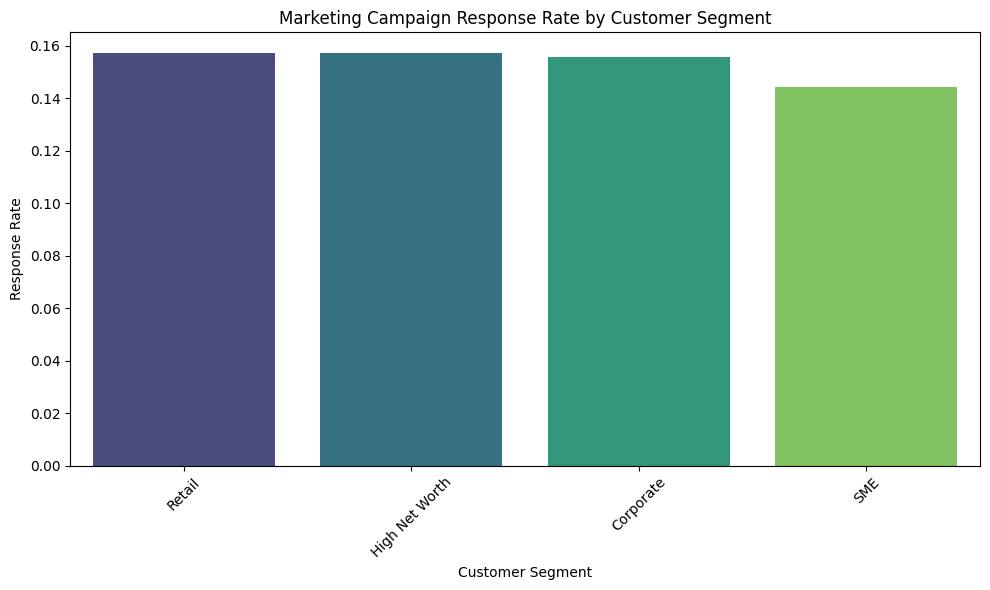

In [3]:
# Calculate response rates by segment
segment_response = df.groupby('segment')['response'].agg(['mean', 'count']).reset_index()
segment_response.columns = ['segment', 'response_rate', 'total_contacts']
segment_response = segment_response.sort_values('response_rate', ascending=False)

display(segment_response)

# Visualize response rates by segment
plt.figure(figsize=(10, 6))
sns.barplot(data=segment_response, x='segment', y='response_rate', palette='viridis')
plt.title('Marketing Campaign Response Rate by Customer Segment')
plt.ylabel('Response Rate')
plt.xlabel('Customer Segment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../../../visualizations/marketing_response_by_segment.png')
plt.show()



## Statistical Testing: Campaign Conversion Rates (Chi-Square)



Contingency Table (Campaign vs Response):


response,0,1
campaign_id,,
C1,2824,530
C2,2835,520
C3,2804,487


Chi-Square Statistic: 1.3523
P-value: 5.0856e-01
Result: No statistically significant difference in conversion rates between campaigns.


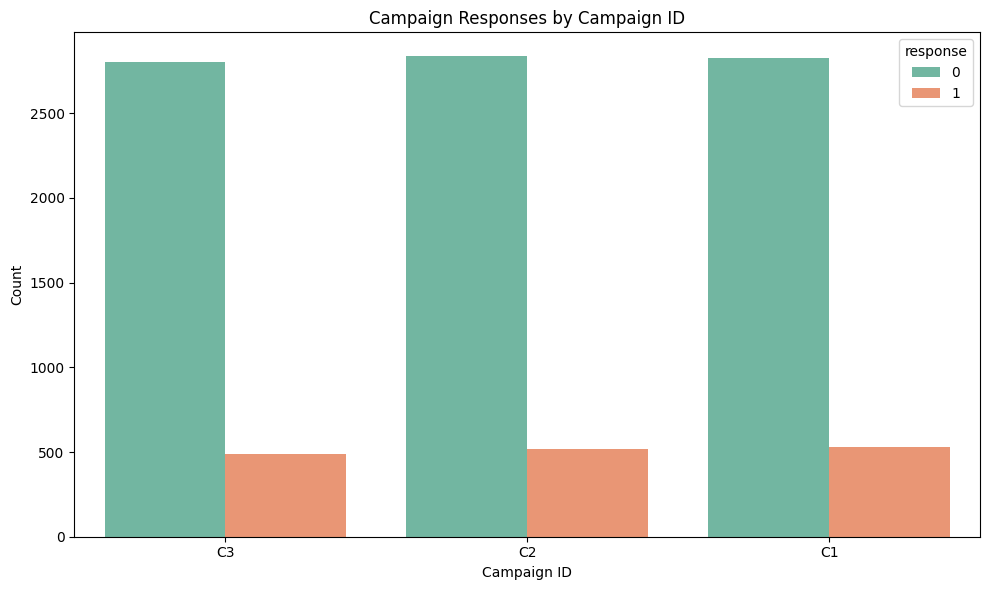

In [4]:
# We use Chi-Square test for independence to see if campaign ID affects response rate
contingency_table = pd.crosstab(df['campaign_id'], df['response'])
print("Contingency Table (Campaign vs Response):")
display(contingency_table)

chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p_val:.4e}")

if p_val < 0.05:
    print("Result: There is a statistically significant difference in conversion rates between campaigns.")
else:
    print("Result: No statistically significant difference in conversion rates between campaigns.")

# Visualize campaign performance
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='campaign_id', hue='response', palette='Set2')
plt.title('Campaign Responses by Campaign ID')
plt.ylabel('Count')
plt.xlabel('Campaign ID')
plt.tight_layout()
plt.savefig('../../../visualizations/marketing_campaign_performance.png')
plt.show()
